In [7]:
!pip uninstall -y transformers datasets accelerate pft

Found existing installation: transformers 4.40.0
Uninstalling transformers-4.40.0:
  Successfully uninstalled transformers-4.40.0
Found existing installation: accelerate 0.30.0
Uninstalling accelerate-0.30.0:
  Successfully uninstalled accelerate-0.30.0


In [8]:
import subprocess, sys

subprocess.check_call([sys.executable, "-m", "pip", "install", "-q",
    "transformers>=4.41.0", "accelerate>=0.30.0", "sentence-transformers>=5.4.0"])

0

In [ ]:
import os
os.kill(os.getpid(), 9)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [3]:
import pandas as pd
import torch
import numpy as np
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split

# =========================
# LOAD DATA
# =========================
df = pd.read_csv("train.csv")

LABEL_COLS = [
    "label_toxic","label_severe","label_obscene",
    "label_threat","label_insult","label_identity_hate","label_offensive"
]

# =========================
# BALANCE DATA (KEY FIX)
# =========================
toxic_df = df[df["label_toxic"] == 1]
non_toxic_df = df[df["label_toxic"] == 0].sample(len(toxic_df)*2, random_state=42)

df_balanced = pd.concat([toxic_df, non_toxic_df]).sample(frac=1, random_state=42)

print("Balanced dataset size:", df_balanced.shape)

# =========================
# SPLIT
# =========================
train_df, val_df = train_test_split(df_balanced, test_size=0.1, random_state=42)

# =========================
# MODEL
# =========================
MODEL_NAME = "xlm-roberta-base"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize(texts):
    return tokenizer(texts, padding="max_length", truncation=True, max_length=128)

# =========================
# DATASET CLASS
# =========================
class Dataset(torch.utils.data.Dataset):
    def __init__(self, df):
        self.encodings = tokenize(df["text"].tolist())
        self.labels = df[LABEL_COLS].values

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k,v in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.float)
        return item

    def __len__(self):
        return len(self.labels)

train_ds = Dataset(train_df)
val_ds = Dataset(val_df)

# =========================
# MODEL INIT
# =========================
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(LABEL_COLS),
    problem_type="multi_label_classification"
)

# =========================
# CUSTOM LOSS (IMPORTANT)
# =========================
class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):  # ✅ added
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits

        pos_weight = torch.tensor([2.0, 2.0, 2.0, 4.0, 2.0, 2.0, 2.0]).to(logits.device)
        loss_fn = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight)
        loss = loss_fn(logits, labels)

        return (loss, outputs) if return_outputs else loss

# =========================
# METRICS
# =========================
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    probs = torch.sigmoid(torch.tensor(logits)).numpy()

    preds = (probs > 0.5).astype(int)  #lower threshold

    return {
        "f1_micro": f1_score(labels, preds, average="micro"),
        "f1_macro": f1_score(labels, preds, average="macro"),
    }

# =========================
# TRAINING CONFIG
# =========================
training_args = TrainingArguments(
    output_dir="model_output",

    eval_strategy="epoch",
    save_strategy="epoch",

    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,

    num_train_epochs=2,
    load_best_model_at_end=True,

    fp16=True,
    logging_steps=100,
)

# =========================
# TRAINER
# =========================
trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    processing_class=tokenizer,
    compute_metrics=compute_metrics
)

# =========================
# TRAIN
# =========================
trainer.train()

# =========================
# SAVE MODEL
# =========================
trainer.save_model("final_model")
tokenizer.save_pretrained("final_model")

print("Training complete")

Balanced dataset size: (46440, 11)


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
classifier.dense.bias       | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.out_proj.weight  | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,F1 Micro,F1 Macro
1,0.212128,0.205630,0.806500,0.651417
2,0.175243,0.194777,0.828538,0.731423


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training complete


In [12]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
import numpy as np

MODEL_PATH = "final_model"

# Reload saved model with eager attention (enables output_attentions)
model = AutoModelForSequenceClassification.from_pretrained(
    "final_model",
    attn_implementation="eager"
).to("cuda")
model.eval()
tokenizer = AutoTokenizer.from_pretrained("final_model")
print("✅ Model reloaded with eager attention")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

✅ Model reloaded with eager attention


In [44]:
LABELS = ["toxic", "severe", "obscene", "threat", "insult", "identity_hate", "offensive"]


In [59]:
def predict(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True).to("cuda")

    with torch.no_grad():
        outputs = model(**inputs)

    probs = torch.sigmoid(outputs.logits).cpu().numpy()[0]
    preds = (probs > 0.3).astype(int)

    result = {LABELS[i]: int(preds[i]) for i in range(len(LABELS))}

    # ✅ Removed forced fallback — if nothing crosses threshold, it's clean text
    return result, probs

In [60]:
def explain(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True).to("cuda")

    with torch.no_grad():
        outputs = model(**inputs, output_attentions=True)

    attentions = outputs.attentions[-1]
    scores = attentions.mean(dim=1).squeeze()

    token_scores = scores.sum(dim=0).cpu().numpy()
    tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])

    clean_tokens = []
    clean_scores = []

    for tok, score in zip(tokens, token_scores):
        if tok in ["<s>", "</s>", "<pad>"]:
            continue
        clean_tokens.append(tok)
        clean_scores.append(score)

    return list(zip(clean_tokens, clean_scores))

In [61]:
def highlight(text, percentile=80):
    token_scores = explain(text)
    tokens, scores = zip(*token_scores)

    threshold = np.percentile(scores, percentile)  # top 20% tokens get highlighted

    words = []
    for token, score in zip(tokens, scores):
        word = token.replace("▁", " ").strip()
        words.append(f"[{word}]" if score > threshold else word)

    return " ".join(words)

In [63]:
text = "I like this movie"

pred, probs = predict(text)

print("Prediction:")
print(display_pred(pred))  # ✅ offensive hidden here only

print("\nHighlighted:")
print(highlight(text))

Prediction:
{'toxic': 0, 'severe': 0, 'obscene': 0, 'threat': 0, 'insult': 0, 'identity_hate': 0}

Highlighted:
[I] like this movie


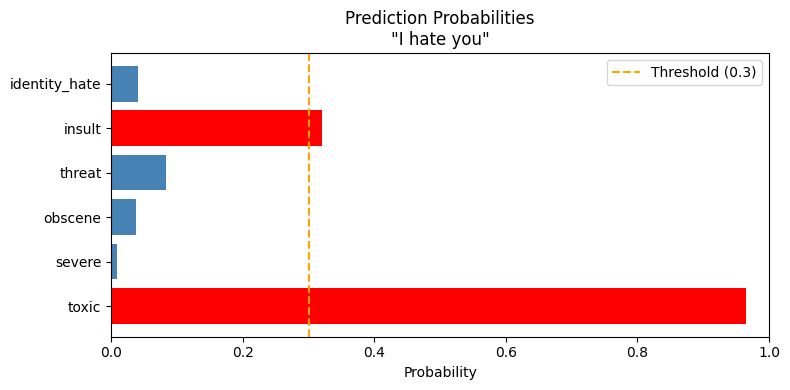

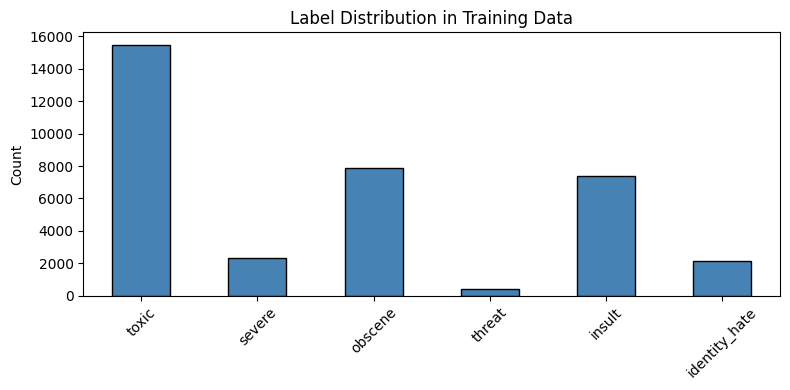

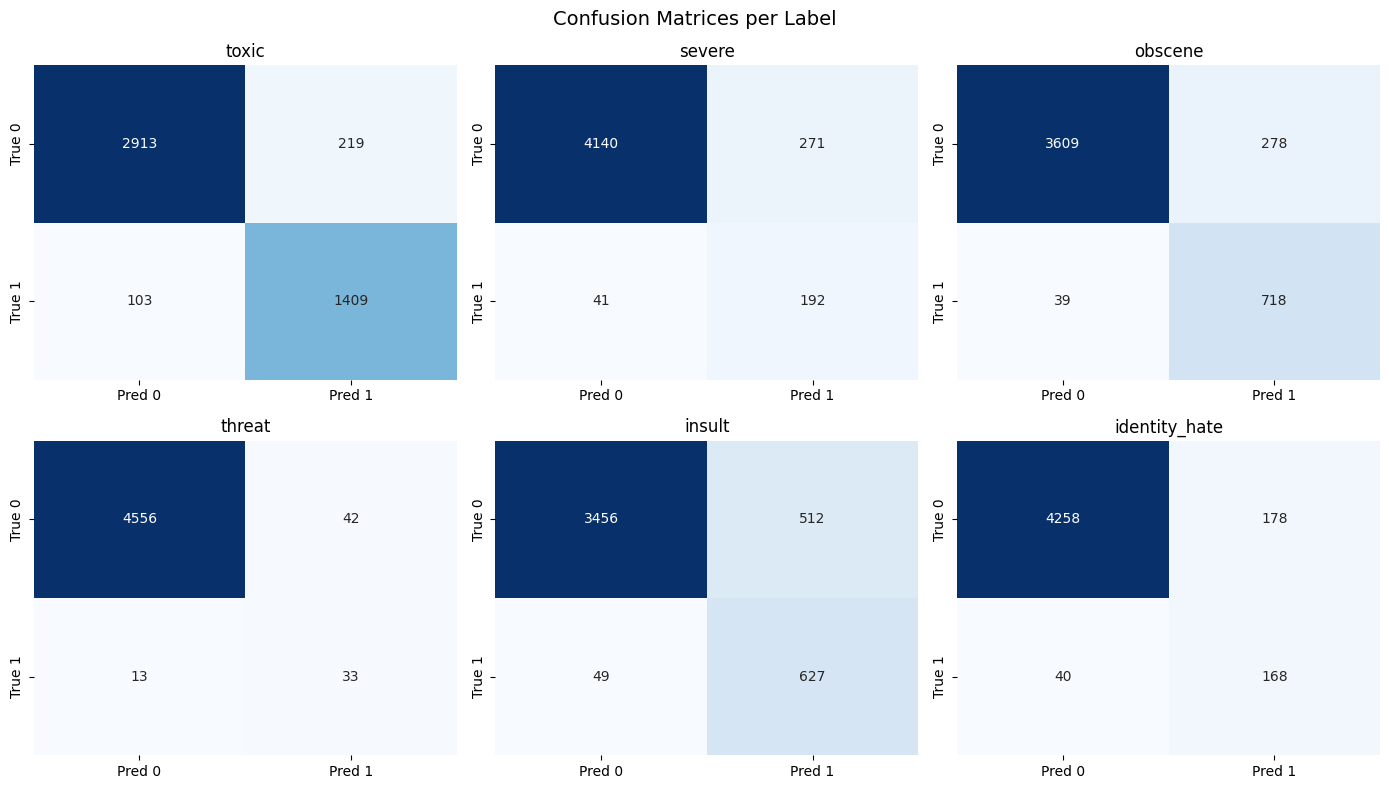

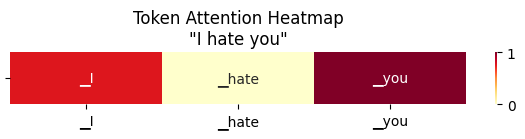

In [65]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

DISPLAY_LABELS = ["toxic", "severe", "obscene", "threat", "insult", "identity_hate"]

# =========================
# 1. PROBABILITY BAR CHART FOR A PREDICTION
# =========================
def plot_probs(text):
    _, probs = predict(text)
    probs_display = probs[:6]  # exclude offensive

    plt.figure(figsize=(8, 4))
    bars = plt.barh(DISPLAY_LABELS, probs_display, color=[
        "red" if p > 0.3 else "steelblue" for p in probs_display
    ])
    plt.axvline(0.3, color="orange", linestyle="--", label="Threshold (0.3)")
    plt.xlabel("Probability")
    plt.title(f"Prediction Probabilities\n\"{text}\"")
    plt.xlim(0, 1)
    plt.legend()
    plt.tight_layout()
    plt.show()

# =========================
# 2. LABEL DISTRIBUTION IN TRAINING DATA
# =========================
def plot_label_distribution(df):
    counts = df[["label_toxic","label_severe","label_obscene",
                 "label_threat","label_insult","label_identity_hate"]].sum()
    counts.index = DISPLAY_LABELS

    plt.figure(figsize=(8, 4))
    counts.plot(kind="bar", color="steelblue", edgecolor="black")
    plt.title("Label Distribution in Training Data")
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# =========================
# 3. CONFUSION MATRIX PER LABEL (on val set)
# =========================
def plot_confusion_matrices(val_df):
    fig, axes = plt.subplots(2, 3, figsize=(14, 8))
    axes = axes.flatten()

    label_cols = ["label_toxic","label_severe","label_obscene",
                  "label_threat","label_insult","label_identity_hate"]

    all_preds = []
    all_labels = val_df[label_cols].values

    for text in val_df["text"].tolist():
        pred, _ = predict(text)
        all_preds.append([pred[l] for l in DISPLAY_LABELS])

    all_preds = np.array(all_preds)

    for i, (col, label) in enumerate(zip(label_cols, DISPLAY_LABELS)):
        cm = confusion_matrix(all_labels[:, i], all_preds[:, i])
        sns.heatmap(cm, annot=True, fmt="d", ax=axes[i],
                    cmap="Blues", cbar=False,
                    xticklabels=["Pred 0","Pred 1"],
                    yticklabels=["True 0","True 1"])
        axes[i].set_title(label)

    plt.suptitle("Confusion Matrices per Label", fontsize=14)
    plt.tight_layout()
    plt.show()

# =========================
# 4. ATTENTION HEATMAP
# =========================
def plot_attention(text):
    token_scores = explain(text)
    tokens, scores = zip(*token_scores)
    scores = np.array(scores)
    scores = (scores - scores.min()) / (scores.max() - scores.min())  # normalize 0-1

    fig, ax = plt.subplots(figsize=(max(6, len(tokens)), 1.5))
    sns.heatmap([scores], annot=[list(tokens)], fmt="",
                cmap="YlOrRd", ax=ax, cbar=True,
                xticklabels=tokens, yticklabels=[""])
    ax.set_title(f"Token Attention Heatmap\n\"{text}\"")
    plt.tight_layout()
    plt.show()

# =========================
# RUN ALL PLOTS
# =========================
test_text = "I hate you"

plot_probs(test_text)
plot_label_distribution(df)                  # needs df loaded
plot_confusion_matrices(val_df)              # needs val_df loaded — may take a few mins
plot_attention(test_text)

Running inference on validation set... (may take a few mins)

📊 Per-Label Metrics:
                  F1  Precision  Recall
Label                                  
toxic          0.897      0.865   0.932
severe         0.552      0.415   0.824
obscene        0.819      0.721   0.948
threat         0.545      0.440   0.717
insult         0.691      0.550   0.928
identity_hate  0.606      0.486   0.808

📈 Overall Metrics:
  F1 Micro:    0.779
  F1 Macro:    0.685
  F1 Weighted: 0.794


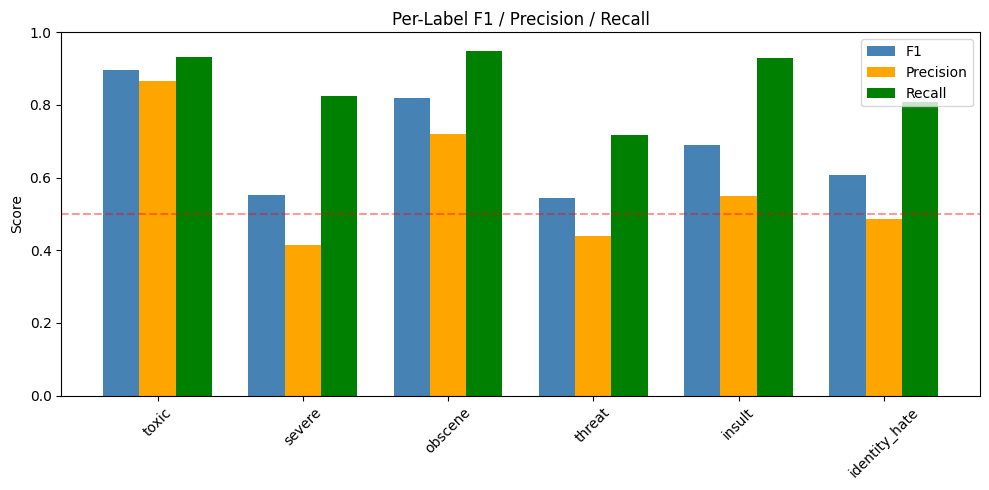


📋 Full Classification Report:
               precision    recall  f1-score   support

        toxic       0.87      0.93      0.90      1512
       severe       0.41      0.82      0.55       233
      obscene       0.72      0.95      0.82       757
       threat       0.44      0.72      0.55        46
       insult       0.55      0.93      0.69       676
identity_hate       0.49      0.81      0.61       208

    micro avg       0.68      0.92      0.78      3432
    macro avg       0.58      0.86      0.69      3432
 weighted avg       0.71      0.92      0.79      3432
  samples avg       0.23      0.29      0.25      3432



In [66]:
from sklearn.metrics import classification_report, f1_score, precision_score, recall_score
import pandas as pd

# =========================
# RUN INFERENCE ON VAL SET
# =========================
print("Running inference on validation set... (may take a few mins)")

label_cols = ["label_toxic","label_severe","label_obscene",
              "label_threat","label_insult","label_identity_hate"]

all_preds = []
all_labels = val_df[label_cols].values

for text in val_df["text"].tolist():
    pred, _ = predict(text)
    all_preds.append([pred[l] for l in DISPLAY_LABELS])

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# =========================
# PER LABEL METRICS TABLE
# =========================
metrics = {
    "Label":     DISPLAY_LABELS,
    "F1":        f1_score(all_labels, all_preds, average=None),
    "Precision": precision_score(all_labels, all_preds, average=None, zero_division=0),
    "Recall":    recall_score(all_labels, all_preds, average=None, zero_division=0),
}

metrics_df = pd.DataFrame(metrics).set_index("Label").round(3)
print("\n📊 Per-Label Metrics:")
print(metrics_df.to_string())

# =========================
# OVERALL METRICS
# =========================
print("\n📈 Overall Metrics:")
print(f"  F1 Micro:    {f1_score(all_labels, all_preds, average='micro'):.3f}")
print(f"  F1 Macro:    {f1_score(all_labels, all_preds, average='macro'):.3f}")
print(f"  F1 Weighted: {f1_score(all_labels, all_preds, average='weighted'):.3f}")

# =========================
# PLOT METRICS BAR CHART
# =========================
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(DISPLAY_LABELS))
width = 0.25

ax.bar(x - width, metrics_df["F1"],        width, label="F1",        color="steelblue")
ax.bar(x,         metrics_df["Precision"], width, label="Precision",  color="orange")
ax.bar(x + width, metrics_df["Recall"],    width, label="Recall",     color="green")

ax.set_xticks(x)
ax.set_xticklabels(DISPLAY_LABELS, rotation=45)
ax.set_ylim(0, 1)
ax.set_ylabel("Score")
ax.set_title("Per-Label F1 / Precision / Recall")
ax.legend()
ax.axhline(0.5, color="red", linestyle="--", alpha=0.4, label="0.5 baseline")
plt.tight_layout()
plt.show()

# =========================
# FULL SKLEARN REPORT
# =========================
print("\n📋 Full Classification Report:")
print(classification_report(all_labels, all_preds, target_names=DISPLAY_LABELS, zero_division=0))